# Systematic evaluation of pseudoknots from dependencies

## Extract pseudoknot structures from bpRNA 90

In [3]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import seaborn as sns
from scipy.signal import convolve2d
import math
import argparse
from collections import OrderedDict
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import time
import random
from tqdm import tqdm


In [4]:
def parse_bpRNA_file(filepath):
    """
    Parse a single bpRNA file to extract:
      - name (str)
      - length (int)
      - page_number (int)
      - sequence (str)
      - dot_bracket (str)
      - n_k_line (str) -> the line containing N's and (possibly) K's

    Returns a dictionary with these keys if a K is found in n_k_line, otherwise None.
    """

    name = None
    length_ = None
    page_number = None
    sequence = None
    dot_bracket = None
    n_k_line = None

    with open(filepath, "r") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    # 1) Collect all lines starting with '#' until we reach a non-# line.
    #    Parse what we need out of them (Name, Length, PageNumber, etc.)
    i = 0
    while i < len(lines) and lines[i].startswith('#'):
        line = lines[i]
        if line.startswith("#Name:"):
            # e.g. "#Name: bpRNA_RFAM_2775"
            name = line.split(":", 1)[1].strip()
        elif line.startswith("#Length:"):
            # e.g. "#Length:  341"
            length_ = line.split(":", 1)[1].strip()
        elif line.startswith("#PageNumber:"):
            # e.g. "#PageNumber: 2"
            page_number = int(line.split(":", 1)[1].strip())
        i += 1

    # By now, i should be at the line of the sequence (assuming the file is well-formed).
    # 2) The next line is the sequence line
    if i < len(lines):
        sequence = lines[i].strip()
        i += 1

    # 3) The next line is the dot bracket line
    if i < len(lines):
        dot_bracket = lines[i].strip()
        i += 1

    # 4) Skip the next line which contains detailed structure information like hairpins, etc.
    #    (We assume there's at least one line here to skip.)
    if i < len(lines):
        i += 1  # skip exactly one line
    
    # 5) The next line is the N/K line
    if i < len(lines):
        n_k_line = lines[i].strip()
        
        if "N" not in n_k_line:
            return None  # this line must contain at least one N (nested structure)

    

    # Once we have these items, we check if 'K' is in n_k_line, meaning there is a pseudoknot
    # Return a dictionary only if there's a K
    if n_k_line and "K" in n_k_line:
        return {
            "name": name,
            "length": length_,
            "page_number": page_number,
            "sequence": sequence,
            "dot_bracket": dot_bracket,
            "nested_vs_pseudoknot": n_k_line
        }
    else:
        return None


def parse_all_bpRNA_in_directory(directory):
    """
    Walks through the given directory, parses all files (you can filter by extension),
    and returns a pandas DataFrame of the structures containing a pseudoknot
    (i.e., at least one 'K' in the N-K line).
    """
    results = []
    
    for filename in tqdm(os.listdir(directory)):
        #print(filename)
        filepath = os.path.join(directory, filename)
        if os.path.isfile(filepath):
            parsed_data = parse_bpRNA_file(filepath)
            if parsed_data:
                # Only append if 'K' was found
                results.append(parsed_data)
    
    # Convert to a DataFrame
    df = pd.DataFrame(
        results,
        columns=["name", "length", "page_number", "sequence", "dot_bracket", "nested_vs_pseudoknot"]
    )
    return df

In [8]:
data_path = 'data'

In [11]:
bp_rna_struct_info_dir = os.path.join(data_path, 'bpRNA/bpRNA_1m_90_STFILES')
pseudoknots_df = parse_all_bpRNA_in_directory(bp_rna_struct_info_dir)

100%|██████████| 28370/28370 [13:54<00:00, 34.01it/s]


In [12]:
pseudoknots_df

,name,length,page_number,sequence,dot_bracket,nested_vs_pseudoknot
0,bpRNA_CRW_12866,503,2,GAUUUAUUGGGCGUAAAGCGAGCGCAGGCGGUUUGAUAAGUCUGAA...,.........((([[.....((((.(.(((.(((((((.((((((((...,NNNNNNNNNNNNKKNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
1,bpRNA_RFAM_2694,376,2,CGAGUCGGCCGGGCGACCGCGUCGGCCGGGGCGACCCGGCCGCCGA...,.(((((((((([[[[[[[.(((((((((........)))))))))....,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
2,bpRNA_RFAM_27861,132,3,GUACUGAAAUGCAUGGUGGGAAAUCAGUGUGAAAUUCAUUGGCUGU...,.(((((........(((((.....(((((.......)))))[[(((...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNKKNNN...
3,bpRNA_RFAM_43127,3716,2,UAACCUUAAAUUAGGUAGGAAUACCUACUAAACUUAAGUAUAUUAA...,.......................((((((.....((....)).......,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
4,bpRNA_RNP_136,383,2,GAAGCUGACCAGACAGUCGCCGCUUCGUCGUCGUCCUCCUUCGGGG...,((((((((((([[[[[[[.(((((((((((((.((((((....)))...,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
...,...,...,...,...,...,...
3315,bpRNA_RFAM_4614,206,2,GCUUAUGAGUUAACGUAAGUCAAGCUCAUGUAAAAUCUGCCUAAAA...,....(((((((((.........)))))))))...(((((.((..((...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
3316,bpRNA_RFAM_23401,125,2,GGUGCCUUUGAAACCAUCUCCUAGGUUUCUUCGGAAGGACUUCGGU...,.((((((..((((((..[[[[[[)))))).......[(((.....)...,NNNNNNNNNNNNNNNNNKKKKKKNNNNNNNNNNNNNKNNNNNNNNN...
3317,bpRNA_CRW_54601,573,2,UAACAAGGUUCGGAGAGACCCGAUGAUCUCUUUCGUGGAGUAUAUA...,....((((((.................((((.....)))).........,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...
3318,bpRNA_CRW_8079,1382,2,UAGAGUUUGAUCCUGGCUCAGAAUGAACGCUGGCGGCAGGCCUAAC...,..(((((...[[[.))))).............(((((((((....(...,NNNNNNNNNNKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...


In [13]:
pseudoknots_df['len_dot_bracket'] = pseudoknots_df['dot_bracket'].apply(len)
pseudoknots_df['len_sequence'] = pseudoknots_df['sequence'].apply(len)

In [14]:
assert pseudoknots_df['len_dot_bracket'].equals(pseudoknots_df['len_sequence'])

In [15]:
pseudoknots_df.iloc[2]['dot_bracket']

'.(((((........(((((.....(((((.......)))))[[(((.{{{))).(((.....]])))....))))))))))............((((..((((.}}}....)))).))))............'

In [16]:
unique_dotbracket_chars = set.union(*list(pseudoknots_df['dot_bracket'].apply(lambda el: set(el)).values))
unique_dotbracket_chars

{'(', ')', '.', '<', '>', 'A', '[', ']', 'a', '{', '}'}

In [17]:
pseudoknot_start_brackets = ['<', '[', '{', 'A'] #this is specified also in the bpRNA paper
pseudoknot_end_brackets = ['>', ']', '}', 'a']

In [18]:
pseudoknot_brackets = [[start, end] for start, end in zip(pseudoknot_start_brackets, pseudoknot_end_brackets)]
pseudoknot_brackets

[['<', '>'], ['[', ']'], ['{', '}'], ['A', 'a']]

In [19]:
def create_contact_matrix(structure, start_bracket='(', end_bracket=')'):
    stack = []
    matrix_size = len(structure)
    contact_matrix = torch.zeros((matrix_size, matrix_size), dtype=int)

    for i, char in enumerate(structure):
        if char == start_bracket:
            stack.append(i)
        elif char == end_bracket and stack:
            j = stack.pop()
            contact_matrix[i,j] = contact_matrix[j,i] = 1

    return contact_matrix


In [20]:
def create_contact_matrix_pseudoknot(structure):
    
    matrix_size = len(structure)
    contact_matrix = torch.zeros((matrix_size, matrix_size), dtype=int)

    #each different bracket type represents fully nested structural contacts. One nuleotide can only contact at most one other nucleotide in this notation
    for bracket_type in pseudoknot_brackets:

        stack = []
        pseudoknot_start_bracket = bracket_type[0]
        pseudoknot_end_bracket = bracket_type[1]

        for i, char in enumerate(structure):
            if char in pseudoknot_start_bracket:
                stack.append(i)
            elif char in pseudoknot_end_bracket and stack:
                j = stack.pop()
                contact_matrix[i,j] = contact_matrix[j,i] = 1

    return contact_matrix

all_brackets = pseudoknot_brackets + [['(', ')']]
def create_contact_matrix_all_contacts(structure):
    
    matrix_size = len(structure)
    contact_matrix = torch.zeros((matrix_size, matrix_size), dtype=int)

    #each different bracket type represents fully nested structural contacts. One nuleotide can only contact at most one other nucleotide in this notation
    for bracket_type in all_brackets:

        stack = []
        start_bracket = bracket_type[0]
        end_bracket = bracket_type[1]

        for i, char in enumerate(structure):
            if char in start_bracket:
                stack.append(i)
            elif char in end_bracket and stack:
                j = stack.pop()
                contact_matrix[i,j] = contact_matrix[j,i] = 1

    return contact_matrix


def create_contact_matrix_no_pseudoknots(structure, start_bracket='(', end_bracket=')'):
    stack = []
    matrix_size = len(structure)
    contact_matrix = torch.zeros((matrix_size, matrix_size), dtype=int)

    for i, char in enumerate(structure):
        if char == start_bracket:
            stack.append(i)
        elif char == end_bracket and stack:
            j = stack.pop()
            contact_matrix[i,j] = contact_matrix[j,i] = 1

    return contact_matrix



In [21]:
toy_example = '((((..(((...)))..)))).'

<Axes: >

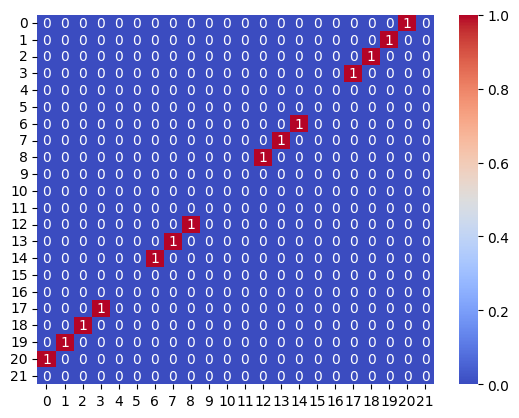

In [22]:
#plot heamatp
sns.heatmap(create_contact_matrix(toy_example), cmap='coolwarm', annot=True)

In [23]:
toy_example = '(((..(([[{{...)).]]}}))).' #example with 2 non nested sets of contacts

<Axes: >

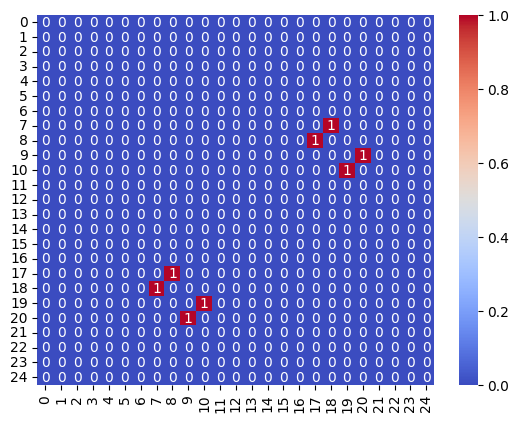

In [24]:
#plot heamatp
sns.heatmap(create_contact_matrix_pseudoknot(toy_example), cmap='coolwarm', annot=True)

<Axes: >

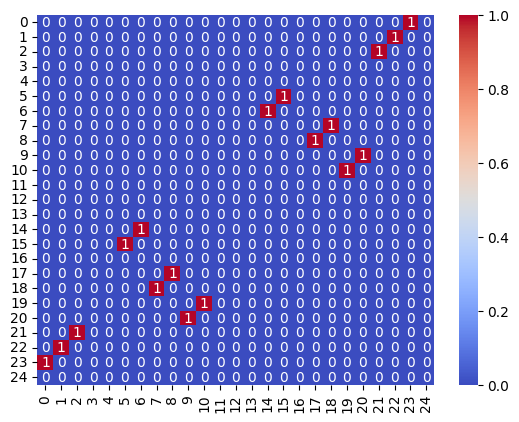

In [25]:
#plot heamatp
sns.heatmap(create_contact_matrix_all_contacts(toy_example), cmap='coolwarm', annot=True)

<Axes: >

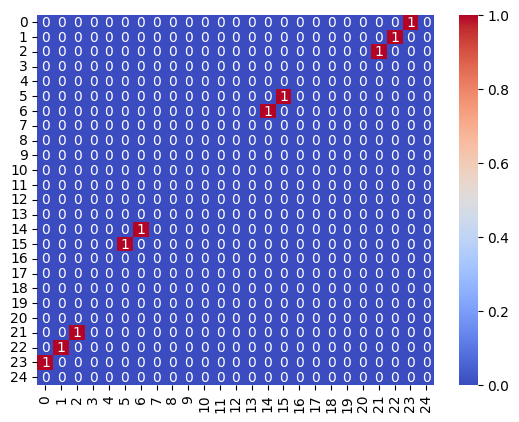

In [26]:
#plot heamatp
sns.heatmap(create_contact_matrix_no_pseudoknots(toy_example), cmap='coolwarm', annot=True)

## Benchmark dependency maps for pseudoknots

In [27]:
pseudoknots_df = pseudoknots_df[pseudoknots_df['len_dot_bracket'] <=1024].reset_index(drop=True).copy()
pseudoknots_df

,name,length,page_number,sequence,dot_bracket,nested_vs_pseudoknot,len_dot_bracket,len_sequence
0,bpRNA_CRW_12866,503,2,GAUUUAUUGGGCGUAAAGCGAGCGCAGGCGGUUUGAUAAGUCUGAA...,.........((([[.....((((.(.(((.(((((((.((((((((...,NNNNNNNNNNNNKKNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,503,503
1,bpRNA_RFAM_2694,376,2,CGAGUCGGCCGGGCGACCGCGUCGGCCGGGGCGACCCGGCCGCCGA...,.(((((((((([[[[[[[.(((((((((........)))))))))....,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,376,376
2,bpRNA_RFAM_27861,132,3,GUACUGAAAUGCAUGGUGGGAAAUCAGUGUGAAAUUCAUUGGCUGU...,.(((((........(((((.....(((((.......)))))[[(((...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNKKNNN...,132,132
3,bpRNA_RNP_136,383,2,GAAGCUGACCAGACAGUCGCCGCUUCGUCGUCGUCCUCCUUCGGGG...,((((((((((([[[[[[[.(((((((((((((.((((((....)))...,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,383,383
4,bpRNA_RFAM_2258,322,2,AGAGUGAAACUCUUUAGAGAGUCAUGGGGCCAUGAGCUGAGUGCUU...,.((((((..(((((((........(((((.........((((((.....,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,322,322
...,...,...,...,...,...,...,...,...
2525,bpRNA_RNP_278,405,2,GCGGAAGACCGGAUGACCGCGGCGGCCCAUAGCUCCGUUUUUCGGA...,((((((((((([[[[[[[.((((((((((((((((((.....))))...,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,405,405
2526,bpRNA_RFAM_4614,206,2,GCUUAUGAGUUAACGUAAGUCAAGCUCAUGUAAAAUCUGCCUAAAA...,....(((((((((.........)))))))))...(((((.((..((...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,206,206
2527,bpRNA_RFAM_23401,125,2,GGUGCCUUUGAAACCAUCUCCUAGGUUUCUUCGGAAGGACUUCGGU...,.((((((..((((((..[[[[[[)))))).......[(((.....)...,NNNNNNNNNNNNNNNNNKKKKKKNNNNNNNNNNNNNKNNNNNNNNN...,125,125
2528,bpRNA_CRW_54601,573,2,UAACAAGGUUCGGAGAGACCCGAUGAUCUCUUUCGUGGAGUAUAUA...,....((((((.................((((.....)))).........,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,573,573


In [31]:
pseudoknots_df.to_csv(os.path.join(data_path, 'bpRNA/pseudoknots_loweq_1024.tsv'), index=False, sep='\t')

In [32]:
pseudoknots_df = pd.read_csv(os.path.join(data_path, 'bpRNA/pseudoknots_loweq_1024.tsv'), sep='\t')
pseudoknots_df

,name,length,page_number,sequence,dot_bracket,nested_vs_pseudoknot,len_dot_bracket,len_sequence
0,bpRNA_CRW_12866,503,2,GAUUUAUUGGGCGUAAAGCGAGCGCAGGCGGUUUGAUAAGUCUGAA...,.........((([[.....((((.(.(((.(((((((.((((((((...,NNNNNNNNNNNNKKNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,503,503
1,bpRNA_RFAM_2694,376,2,CGAGUCGGCCGGGCGACCGCGUCGGCCGGGGCGACCCGGCCGCCGA...,.(((((((((([[[[[[[.(((((((((........)))))))))....,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,376,376
2,bpRNA_RFAM_27861,132,3,GUACUGAAAUGCAUGGUGGGAAAUCAGUGUGAAAUUCAUUGGCUGU...,.(((((........(((((.....(((((.......)))))[[(((...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNKKNNN...,132,132
3,bpRNA_RNP_136,383,2,GAAGCUGACCAGACAGUCGCCGCUUCGUCGUCGUCCUCCUUCGGGG...,((((((((((([[[[[[[.(((((((((((((.((((((....)))...,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,383,383
4,bpRNA_RFAM_2258,322,2,AGAGUGAAACUCUUUAGAGAGUCAUGGGGCCAUGAGCUGAGUGCUU...,.((((((..(((((((........(((((.........((((((.....,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,322,322
...,...,...,...,...,...,...,...,...
2525,bpRNA_RNP_278,405,2,GCGGAAGACCGGAUGACCGCGGCGGCCCAUAGCUCCGUUUUUCGGA...,((((((((((([[[[[[[.((((((((((((((((((.....))))...,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,405,405
2526,bpRNA_RFAM_4614,206,2,GCUUAUGAGUUAACGUAAGUCAAGCUCAUGUAAAAUCUGCCUAAAA...,....(((((((((.........)))))))))...(((((.((..((...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,206,206
2527,bpRNA_RFAM_23401,125,2,GGUGCCUUUGAAACCAUCUCCUAGGUUUCUUCGGAAGGACUUCGGU...,.((((((..((((((..[[[[[[)))))).......[(((.....)...,NNNNNNNNNNNNNNNNNKKKKKKNNNNNNNNNNNNNKNNNNNNNNN...,125,125
2528,bpRNA_CRW_54601,573,2,UAACAAGGUUCGGAGAGACCCGAUGAUCUCUUUCGUGGAGUAUAUA...,....((((((.................((((.....)))).........,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,573,573


### Loading RINALMo

In [33]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.signal import convolve2d
import math
import argparse
from collections import OrderedDict
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import time
import random


In [34]:
import torch
from rinalmo.pretrained import get_pretrained_model

device = "cuda:0"


In [35]:

model, alphabet = get_pretrained_model(model_name="giga-v1")
model = model.to(device=device)
model.eval()
seqs = ["ACUUUGGCCA", "CCCGGU", "ACGU"]

tokens = torch.tensor(alphabet.batch_tokenize(seqs), dtype=torch.int64, device=device)

In [36]:
nuc_table = {"A" : 0, "C":1, "G":2, "U":3} # For RINALMo we have Us instead of Ts

def mutate_sequence(seq):
    seq = seq.upper()
    mutated_sequences = {'seq':[], 'mutation_pos':[], 'nuc':[], 'var_nt_idx':[]} #,'gene_id': []}
    #mutated_sequences['gene_id'].append(gene_id)
    mutated_sequences['seq'].append(seq)
    mutated_sequences['mutation_pos'].append(-1)
    mutated_sequences['nuc'].append('real sequence')
    mutated_sequences['var_nt_idx'].append(-1)


    mutate_until_position = len(seq)

    for i in range(mutate_until_position):
        for nuc in ['A', 'C', 'G', 'U']:
            if nuc != seq[i]:
                #mutated_sequences['gene_id'].append(gene_id)
                mutated_sequences['seq'].append(seq[:i] + nuc + seq[i+1:])
                mutated_sequences['mutation_pos'].append(i)
                mutated_sequences['nuc'].append(nuc)
                mutated_sequences['var_nt_idx'].append(nuc_table[nuc])

    mutations_df = pd.DataFrame(mutated_sequences)

    return mutations_df

In [37]:
import torch
from torch.utils.data import Dataset, DataLoader

class RNADataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

def custom_collate_fn(batch):

    # batch is a list of sequences
    tokenized_batch = torch.tensor(alphabet.batch_tokenize(batch), 
                                   dtype=torch.int64, 
                                   device=device)
    return tokenized_batch

batch_size = 64

def create_dataloader(dataset, batch_size=batch_size):
    rna_dataset = RNADataset(list(dataset['seq'].values))
    data_loader = DataLoader(rna_dataset, 
                            batch_size=batch_size, 
                            shuffle=False,
                            collate_fn=custom_collate_fn)
    return data_loader

In [38]:
acgu_idxs = [5, 6, 7, 8]
def model_inference(model, data_loader):

    print(f'Inferencing {len(data_loader)} batches')
    output_arrays = []
    for i, batch_tokens in enumerate(data_loader):
        # get some tokenized sequences (B, L_in)
        
        with torch.no_grad(), torch.cuda.amp.autocast():
            outputs = model(batch_tokens)['logits'].cpu().to(torch.float32)
        output_probs = torch.nn.functional.softmax(outputs, dim=-1)[:,:,acgu_idxs] # B, L_seq, 4
        output_arrays.append(output_probs) 

    print(f'Inferencing done')

    # rebuild to nseqs, L_seq, 4
    snp_reconstruct = torch.concat(output_arrays, axis=0)

    return snp_reconstruct.to(torch.float32).numpy()

In [39]:
def compute_ci_matrix(gene_seq,  get_logit=True, effect_on_ref_only = False):

    dataset = mutate_sequence(gene_seq) 
    data_loader = create_dataloader(dataset)
    snp_reconstruct = model_inference(model, data_loader)
    snp_reconstruct = snp_reconstruct[:,1:-1,:] # discard the beginning of sentence token and end of sentence token
    print(snp_reconstruct.shape)

    non_zero_log_value = 1e-10 #due to the conversion to bfloat16, we need to add a small value to avoid log(0)

    if get_logit: # for the logit add the small value and renormalize such that every prob in one position sums to 1
        snp_reconstruct = snp_reconstruct + non_zero_log_value
        snp_reconstruct = snp_reconstruct/snp_reconstruct.sum(axis=-1)[:,:, np.newaxis]

    seq_len = snp_reconstruct.shape[1]
    snp_effect = np.zeros((seq_len, seq_len,4, 4))
    reference_probs = snp_reconstruct[dataset[dataset['nuc'] == 'real sequence'].index[0]]

    print('shape of the reference probs:', reference_probs.shape)

    if get_logit:
        snp_effect[dataset.iloc[1:]['mutation_pos'].values, : ,  dataset.iloc[1:]['var_nt_idx'].values,:] = np.log2(snp_reconstruct[1:]) - np.log2(1 - snp_reconstruct[1:]) \
            - np.log2(reference_probs) + np.log2(1-reference_probs)
    else:
        snp_effect[dataset.iloc[1:]['mutation_pos'].values, : ,  dataset.iloc[1:]['var_nt_idx'].values,:] = np.log2(snp_reconstruct[1:]+non_zero_log_value) - np.log2(reference_probs+non_zero_log_value)

    if effect_on_ref_only:
        gene_seq_int = dataset.iloc[1:].groupby('mutation_pos').apply(lambda pos_df: (set(range(4)) - set(pos_df['var_nt_idx'])).pop()).values
        snp_effect_on_ref = snp_effect[:,np.arange(seq_len),:, gene_seq_int]
        ci_matrix = np.max(np.abs(snp_effect_on_ref), axis=2)

    else:
        ci_matrix = np.max(np.abs(snp_effect), axis=(2,3))

    return ci_matrix

def plot_ci_matrix(ci_matrix, vmax=None, figsize=[10, 10]):#increase figure size
    ci_matrix[np.arange(ci_matrix.shape[0]), np.arange(ci_matrix.shape[0])] = 0
    plt.rcParams['figure.figsize'] = figsize
    plt.imshow(ci_matrix, cmap="coolwarm", vmax=vmax) if vmax is not None else plt.imshow(ci_matrix, cmap="coolwarm")
    return plt

In [40]:
pseudoknots_df

,name,length,page_number,sequence,dot_bracket,nested_vs_pseudoknot,len_dot_bracket,len_sequence
0,bpRNA_CRW_12866,503,2,GAUUUAUUGGGCGUAAAGCGAGCGCAGGCGGUUUGAUAAGUCUGAA...,.........((([[.....((((.(.(((.(((((((.((((((((...,NNNNNNNNNNNNKKNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,503,503
1,bpRNA_RFAM_2694,376,2,CGAGUCGGCCGGGCGACCGCGUCGGCCGGGGCGACCCGGCCGCCGA...,.(((((((((([[[[[[[.(((((((((........)))))))))....,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,376,376
2,bpRNA_RFAM_27861,132,3,GUACUGAAAUGCAUGGUGGGAAAUCAGUGUGAAAUUCAUUGGCUGU...,.(((((........(((((.....(((((.......)))))[[(((...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNKKNNN...,132,132
3,bpRNA_RNP_136,383,2,GAAGCUGACCAGACAGUCGCCGCUUCGUCGUCGUCCUCCUUCGGGG...,((((((((((([[[[[[[.(((((((((((((.((((((....)))...,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,383,383
4,bpRNA_RFAM_2258,322,2,AGAGUGAAACUCUUUAGAGAGUCAUGGGGCCAUGAGCUGAGUGCUU...,.((((((..(((((((........(((((.........((((((.....,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,322,322
...,...,...,...,...,...,...,...,...
2525,bpRNA_RNP_278,405,2,GCGGAAGACCGGAUGACCGCGGCGGCCCAUAGCUCCGUUUUUCGGA...,((((((((((([[[[[[[.((((((((((((((((((.....))))...,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,405,405
2526,bpRNA_RFAM_4614,206,2,GCUUAUGAGUUAACGUAAGUCAAGCUCAUGUAAAAUCUGCCUAAAA...,....(((((((((.........)))))))))...(((((.((..((...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,206,206
2527,bpRNA_RFAM_23401,125,2,GGUGCCUUUGAAACCAUCUCCUAGGUUUCUUCGGAAGGACUUCGGU...,.((((((..((((((..[[[[[[)))))).......[(((.....)...,NNNNNNNNNNNNNNNNNKKKKKKNNNNNNNNNNNNNKNNNNNNNNN...,125,125
2528,bpRNA_CRW_54601,573,2,UAACAAGGUUCGGAGAGACCCGAUGAUCUCUUUCGUGGAGUAUAUA...,....((((((.................((((.....)))).........,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,573,573


In [41]:
folder_output = os.path.join(data_path, "bpRNA/dep_maps")

In [ ]:
import tqdm 


if not os.path.exists(folder_output):
    os.mkdir(folder_output)

for index, row in tqdm.tqdm(pseudoknots_df.iterrows()):
    
    sequence = row["sequence"].replace('T', 'U').upper()
    seq_id = f"{row['name']}"
    
    file_npy = os.path.join(folder_output, f"{seq_id}.npy")
    if not os.path.exists(file_npy):
        
        ci_matrix = compute_ci_matrix(sequence)
        np.save(file_npy, ci_matrix)


In [42]:
def get_ci_matrix(seq_name):
    filename = os.path.join(folder_output, f"{seq_name}.npy")
    return np.load(filename)


In [45]:
seq_name = 'bpRNA_RFAM_2694'

In [46]:
dep_map = get_ci_matrix(seq_name)
dep_map.shape

(376, 376)

<module 'matplotlib.pyplot' from '/opt/modules/i12g/anaconda/envs/flash2/lib/python3.8/site-packages/matplotlib/pyplot.py'>

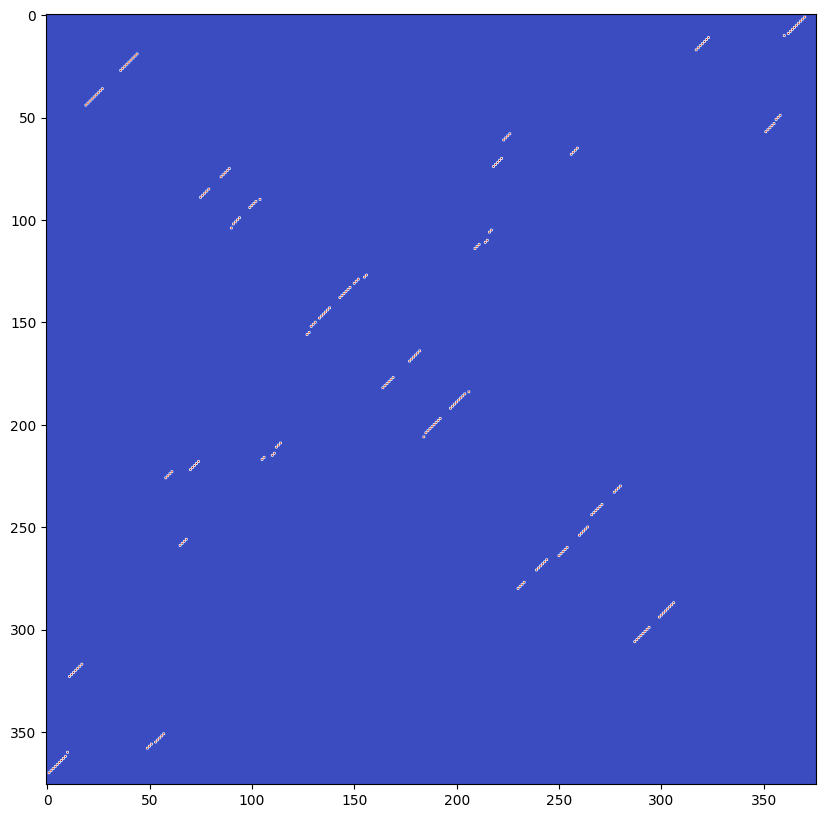

In [47]:
plot_ci_matrix(create_contact_matrix_all_contacts(pseudoknots_df[pseudoknots_df['name'] == seq_name].iloc[0]['dot_bracket']), vmax=1)

<module 'matplotlib.pyplot' from '/opt/modules/i12g/anaconda/envs/flash2/lib/python3.8/site-packages/matplotlib/pyplot.py'>

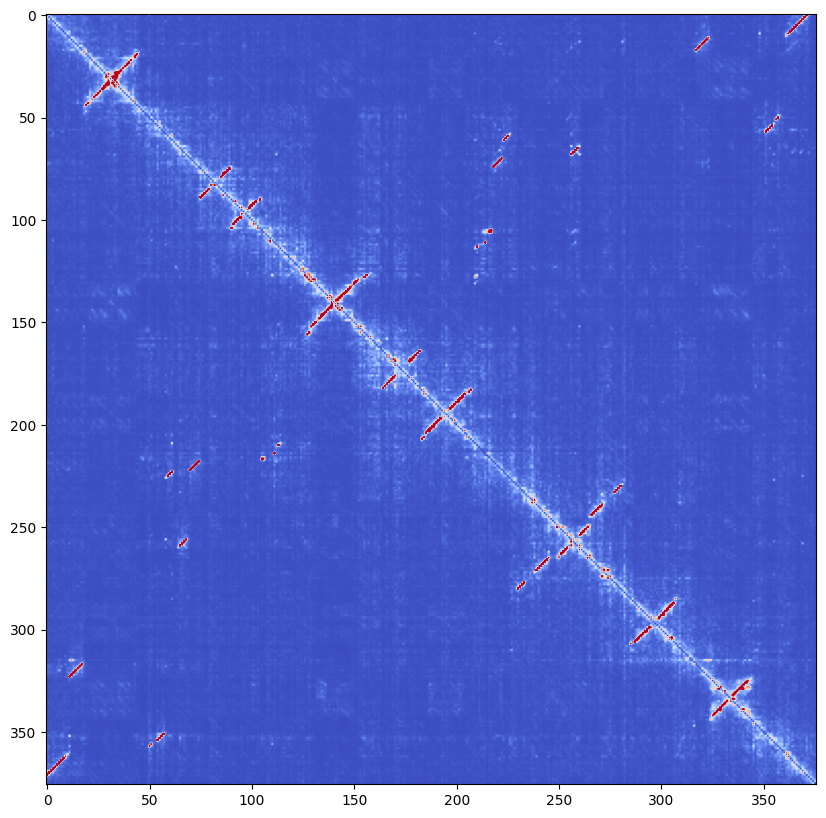

In [48]:
plot_ci_matrix(dep_map, vmax=5, figsize=[10,10])

<module 'matplotlib.pyplot' from '/opt/modules/i12g/anaconda/envs/flash2/lib/python3.8/site-packages/matplotlib/pyplot.py'>

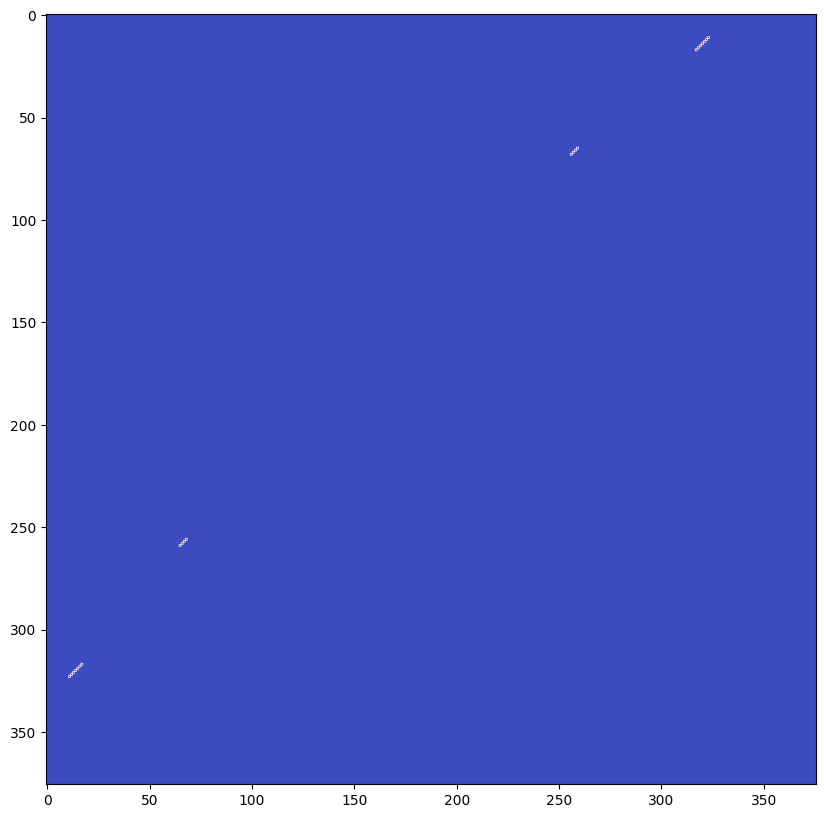

In [49]:
plot_ci_matrix(create_contact_matrix_pseudoknot(pseudoknots_df[pseudoknots_df['name'] == seq_name].iloc[0]['dot_bracket']), vmax=1)

In [50]:
from sklearn.metrics import average_precision_score, roc_auc_score

def create_diag_mask(mask_width = 9, matrix_size = 5): 

    mask = np.zeros((matrix_size, matrix_size))

    for k in range(-mask_width // 2 + 1, mask_width // 2 + 1):
        mask += np.diag(np.ones(matrix_size - abs(k)), k=k)

    mask = 1 - mask
    return mask

def get_triangular_values(matrix):
    
    triang_mask = np.tri(matrix.shape[0],k=-1, dtype=bool)
    
    triangular_flattened = matrix[triang_mask]
    
    return triangular_flattened

def process_ci_matrix(matrix, mask_diag=1, get_max_ij_ji=True):

    if get_max_ij_ji:
        matrix = np.maximum(matrix, matrix.T)
    if mask_diag is not None:
        matrix = matrix * create_diag_mask(mask_width = mask_diag, matrix_size = matrix.shape[0])

    return matrix

In [51]:
for i, row in pseudoknots_df.iterrows():
    seq_name = row['name']
    dot_bracket = row['dot_bracket']
    if i==1:
        break

In [52]:
seq_name, dot_bracket

('bpRNA_RFAM_2694',
 '.(((((((((([[[[[[[.(((((((((........)))))))))....(((.(((((((((...[[[[.((((((((((.....)))))(((((....)))).)((...(((((............(((((.((((((....)))))).)))..)).......((((((.......)))))).(((((((((....)))))))).)..)))..)))))))))))))...((((.....((((((.....(((((.]]]]))))).)))))).....))))......((((((((....))))))))..........]]]]]]]...........................)))))))).).))))))))).....')

In [53]:
dep_map = get_ci_matrix(row['name'])

dep_map_values = get_triangular_values(process_ci_matrix(dep_map, get_max_ij_ji=True, mask_diag=1))
gt_non_pseudoknot_contacts = get_triangular_values(create_contact_matrix_no_pseudoknots(row['dot_bracket']).numpy())
gt_pseudoknot_contacts = get_triangular_values(create_contact_matrix_pseudoknot(row['dot_bracket']).numpy())


In [54]:
create_contact_matrix_no_pseudoknots(row['dot_bracket']).numpy()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [55]:
dep_map_values.shape

(70500,)

In [56]:
dep_map_values[gt_non_pseudoknot_contacts!=1].shape

(70398,)

In [57]:
from sklearn.metrics import roc_auc_score

auroc = roc_auc_score(gt_pseudoknot_contacts[gt_non_pseudoknot_contacts!=1], dep_map_values[gt_non_pseudoknot_contacts!=1])

In [58]:
auroc

0.9999250894728753

In [59]:
from tqdm import tqdm

auroc_list = []
seq_names = []

for i, row in tqdm(pseudoknots_df.iterrows()):

    seq_name = row['name']
    dot_bracket = row['dot_bracket']

    dep_map = get_ci_matrix(row['name'])

    dep_map_values = get_triangular_values(process_ci_matrix(dep_map, get_max_ij_ji=True, mask_diag=1))
    gt_non_pseudoknot_contacts = get_triangular_values(create_contact_matrix_no_pseudoknots(row['dot_bracket']).numpy())
    gt_pseudoknot_contacts = get_triangular_values(create_contact_matrix_pseudoknot(row['dot_bracket']).numpy())

    auroc = roc_auc_score(gt_pseudoknot_contacts[gt_non_pseudoknot_contacts!=1], dep_map_values[gt_non_pseudoknot_contacts!=1])

    auroc_list.append(auroc)
    seq_names.append(seq_name)

performance_df = pd.DataFrame({'seq_name': seq_names, 'auroc': auroc_list})
performance_df

2530it [04:24,  9.57it/s]


,seq_name,auroc
0,bpRNA_CRW_12866,0.417921
1,bpRNA_RFAM_2694,0.999925
2,bpRNA_RFAM_27861,0.691082
3,bpRNA_RNP_136,0.995790
4,bpRNA_RFAM_2258,0.913001
...,...,...
2525,bpRNA_RNP_278,0.997526
2526,bpRNA_RFAM_4614,0.906390
2527,bpRNA_RFAM_23401,0.669698
2528,bpRNA_CRW_54601,0.995764


In [60]:
from plotnine import *
cowplot_theme = theme(
    # Set the background to white and remove panel border
    panel_background=element_blank(),
    panel_border=element_blank(),

    # Light grey grid lines
    panel_grid_major=element_line(color='lightgrey', size=0.5),
    panel_grid_minor=element_blank(),

    # Minimize axis ticks
    axis_ticks=element_blank(),

    # Simple font
    text=element_text(color='black'),
    figure_size = (7,4.5)
)

In [61]:
performance_df = pseudoknots_df.merge(performance_df, left_on='name', right_on='seq_name')
performance_df

,name,length,page_number,sequence,dot_bracket,nested_vs_pseudoknot,len_dot_bracket,len_sequence,seq_name,auroc
0,bpRNA_CRW_12866,503,2,GAUUUAUUGGGCGUAAAGCGAGCGCAGGCGGUUUGAUAAGUCUGAA...,.........((([[.....((((.(.(((.(((((((.((((((((...,NNNNNNNNNNNNKKNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,503,503,bpRNA_CRW_12866,0.417921
1,bpRNA_RFAM_2694,376,2,CGAGUCGGCCGGGCGACCGCGUCGGCCGGGGCGACCCGGCCGCCGA...,.(((((((((([[[[[[[.(((((((((........)))))))))....,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,376,376,bpRNA_RFAM_2694,0.999925
2,bpRNA_RFAM_27861,132,3,GUACUGAAAUGCAUGGUGGGAAAUCAGUGUGAAAUUCAUUGGCUGU...,.(((((........(((((.....(((((.......)))))[[(((...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNKKNNN...,132,132,bpRNA_RFAM_27861,0.691082
3,bpRNA_RNP_136,383,2,GAAGCUGACCAGACAGUCGCCGCUUCGUCGUCGUCCUCCUUCGGGG...,((((((((((([[[[[[[.(((((((((((((.((((((....)))...,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,383,383,bpRNA_RNP_136,0.995790
4,bpRNA_RFAM_2258,322,2,AGAGUGAAACUCUUUAGAGAGUCAUGGGGCCAUGAGCUGAGUGCUU...,.((((((..(((((((........(((((.........((((((.....,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,322,322,bpRNA_RFAM_2258,0.913001
...,...,...,...,...,...,...,...,...,...,...
2525,bpRNA_RNP_278,405,2,GCGGAAGACCGGAUGACCGCGGCGGCCCAUAGCUCCGUUUUUCGGA...,((((((((((([[[[[[[.((((((((((((((((((.....))))...,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,405,405,bpRNA_RNP_278,0.997526
2526,bpRNA_RFAM_4614,206,2,GCUUAUGAGUUAACGUAAGUCAAGCUCAUGUAAAAUCUGCCUAAAA...,....(((((((((.........)))))))))...(((((.((..((...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,206,206,bpRNA_RFAM_4614,0.906390
2527,bpRNA_RFAM_23401,125,2,GGUGCCUUUGAAACCAUCUCCUAGGUUUCUUCGGAAGGACUUCGGU...,.((((((..((((((..[[[[[[)))))).......[(((.....)...,NNNNNNNNNNNNNNNNNKKKKKKNNNNNNNNNNNNNKNNNNNNNNN...,125,125,bpRNA_RFAM_23401,0.669698
2528,bpRNA_CRW_54601,573,2,UAACAAGGUUCGGAGAGACCCGAUGAUCUCUUUCGUGGAGUAUAUA...,....((((((.................((((.....)))).........,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,573,573,bpRNA_CRW_54601,0.995764


In [62]:
performance_df['source'] = performance_df['name'].apply(lambda x: x.split('_')[1])
performance_df

,name,length,page_number,sequence,dot_bracket,nested_vs_pseudoknot,len_dot_bracket,len_sequence,seq_name,auroc,source
0,bpRNA_CRW_12866,503,2,GAUUUAUUGGGCGUAAAGCGAGCGCAGGCGGUUUGAUAAGUCUGAA...,.........((([[.....((((.(.(((.(((((((.((((((((...,NNNNNNNNNNNNKKNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,503,503,bpRNA_CRW_12866,0.417921,CRW
1,bpRNA_RFAM_2694,376,2,CGAGUCGGCCGGGCGACCGCGUCGGCCGGGGCGACCCGGCCGCCGA...,.(((((((((([[[[[[[.(((((((((........)))))))))....,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,376,376,bpRNA_RFAM_2694,0.999925,RFAM
2,bpRNA_RFAM_27861,132,3,GUACUGAAAUGCAUGGUGGGAAAUCAGUGUGAAAUUCAUUGGCUGU...,.(((((........(((((.....(((((.......)))))[[(((...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNKKNNN...,132,132,bpRNA_RFAM_27861,0.691082,RFAM
3,bpRNA_RNP_136,383,2,GAAGCUGACCAGACAGUCGCCGCUUCGUCGUCGUCCUCCUUCGGGG...,((((((((((([[[[[[[.(((((((((((((.((((((....)))...,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,383,383,bpRNA_RNP_136,0.995790,RNP
4,bpRNA_RFAM_2258,322,2,AGAGUGAAACUCUUUAGAGAGUCAUGGGGCCAUGAGCUGAGUGCUU...,.((((((..(((((((........(((((.........((((((.....,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,322,322,bpRNA_RFAM_2258,0.913001,RFAM
...,...,...,...,...,...,...,...,...,...,...,...
2525,bpRNA_RNP_278,405,2,GCGGAAGACCGGAUGACCGCGGCGGCCCAUAGCUCCGUUUUUCGGA...,((((((((((([[[[[[[.((((((((((((((((((.....))))...,NNNNNNNNNNNKKKKKKKNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,405,405,bpRNA_RNP_278,0.997526,RNP
2526,bpRNA_RFAM_4614,206,2,GCUUAUGAGUUAACGUAAGUCAAGCUCAUGUAAAAUCUGCCUAAAA...,....(((((((((.........)))))))))...(((((.((..((...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,206,206,bpRNA_RFAM_4614,0.906390,RFAM
2527,bpRNA_RFAM_23401,125,2,GGUGCCUUUGAAACCAUCUCCUAGGUUUCUUCGGAAGGACUUCGGU...,.((((((..((((((..[[[[[[)))))).......[(((.....)...,NNNNNNNNNNNNNNNNNKKKKKKNNNNNNNNNNNNNKNNNNNNNNN...,125,125,bpRNA_RFAM_23401,0.669698,RFAM
2528,bpRNA_CRW_54601,573,2,UAACAAGGUUCGGAGAGACCCGAUGAUCUCUUUCGUGGAGUAUAUA...,....((((((.................((((.....)))).........,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,573,573,bpRNA_CRW_54601,0.995764,CRW


## Performance aggregated across all structures

In [63]:
from tqdm import tqdm


seq_names = []
dep_map_values_list = []
gt_non_pseudoknot_contacts_list = []
gt_pseudoknot_contacts_list = []

for i, row in tqdm(pseudoknots_df.iterrows()):

    seq_name = row['name']
    dot_bracket = row['dot_bracket']

    dep_map = get_ci_matrix(row['name'])

    dep_map_values = get_triangular_values(process_ci_matrix(dep_map, get_max_ij_ji=True, mask_diag=1))
    gt_non_pseudoknot_contacts = get_triangular_values(create_contact_matrix_no_pseudoknots(row['dot_bracket']).numpy())
    gt_pseudoknot_contacts = get_triangular_values(create_contact_matrix_pseudoknot(row['dot_bracket']).numpy())

    dep_map_values_list.append(dep_map_values)
    gt_non_pseudoknot_contacts_list.append(gt_non_pseudoknot_contacts)
    gt_pseudoknot_contacts_list.append(gt_pseudoknot_contacts)
    seq_names.append(seq_name)

2530it [01:39, 25.38it/s] 


In [64]:
dep_map_values_list[0].shape

(126253,)

In [65]:
all_dep_maps = np.concatenate(dep_map_values_list)
all_gt_non_pseudoknot_contacts = np.concatenate(gt_non_pseudoknot_contacts_list)
all_gt_pseudoknot_contacts = np.concatenate(gt_pseudoknot_contacts_list)

In [66]:
assert all_dep_maps.shape == all_gt_non_pseudoknot_contacts.shape == all_gt_pseudoknot_contacts.shape

In [67]:
#import the precision recall and roc curve functions
from sklearn.metrics import roc_curve    

fpr,tpr,_ = roc_curve(all_gt_pseudoknot_contacts[all_gt_non_pseudoknot_contacts!=1], all_dep_maps[all_gt_non_pseudoknot_contacts!=1])

In [68]:
roc_auc = roc_auc_score(all_gt_pseudoknot_contacts[all_gt_non_pseudoknot_contacts!=1], all_dep_maps[all_gt_non_pseudoknot_contacts!=1])

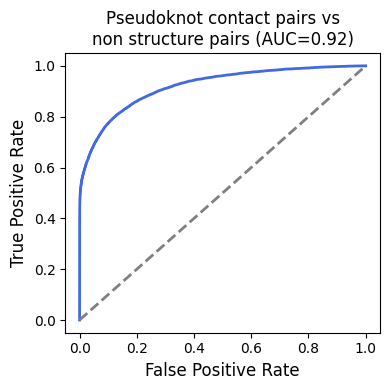

In [69]:
#plot roc curve
plt.figure(figsize=(4,4))

plt.plot(fpr, tpr, color='royalblue', lw=2)
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Pseudoknot contact pairs vs\nnon structure pairs (AUC=%0.2f)' % roc_auc)
# Make sure labels aren’t cut off
plt.tight_layout()

In [70]:
preds_gt_df = pd.DataFrame({'preds': all_dep_maps[all_gt_non_pseudoknot_contacts!=1], 'gt': all_gt_pseudoknot_contacts[all_gt_non_pseudoknot_contacts!=1]})
preds_gt_df

,preds,gt
0,6.384431,0
1,4.661326,0
2,6.440030,0
3,3.617177,0
4,4.554546,0
...,...,...
175037175,0.724466,0
175037176,0.834991,0
175037177,0.776395,0
175037178,0.864101,0


In [71]:
preds_gt_df.to_csv(os.path.join(data_path, 'bpRNA/pseudoknots_preds_gt.tsv'), sep='\t', index=False)

In [72]:
preds_gt_df['gt'] = preds_gt_df['gt'].apply(lambda x: 'Pseudoknot\ncontact' if x==1 else 'Non-structure')

In [73]:
preds_gt_df['gt'].value_counts()

gt
Non-structure          175016129
Pseudoknot\ncontact        21051
Name: count, dtype: int64

In [74]:
from scipy.stats import ranksums
ranksums(preds_gt_df[preds_gt_df['gt'] == 'Pseudoknot\ncontact']['preds'], preds_gt_df[preds_gt_df['gt'] == 'Non-structure']['preds'])

RanksumsResult(statistic=210.82390816573084, pvalue=0.0)

In [75]:
from plotnine import *
cowplot_theme = theme(
    # Set the background to white and remove panel border
    panel_background=element_blank(),
    panel_border=element_blank(),

    # Light grey grid lines
    panel_grid_major=element_line(color='lightgrey', size=0.5),
    panel_grid_minor=element_blank(),

    # Minimize axis ticks
    axis_ticks=element_blank(),

    # Simple font
    text=element_text(color='black', size=12),
    figure_size = (3.5,4.5)
)

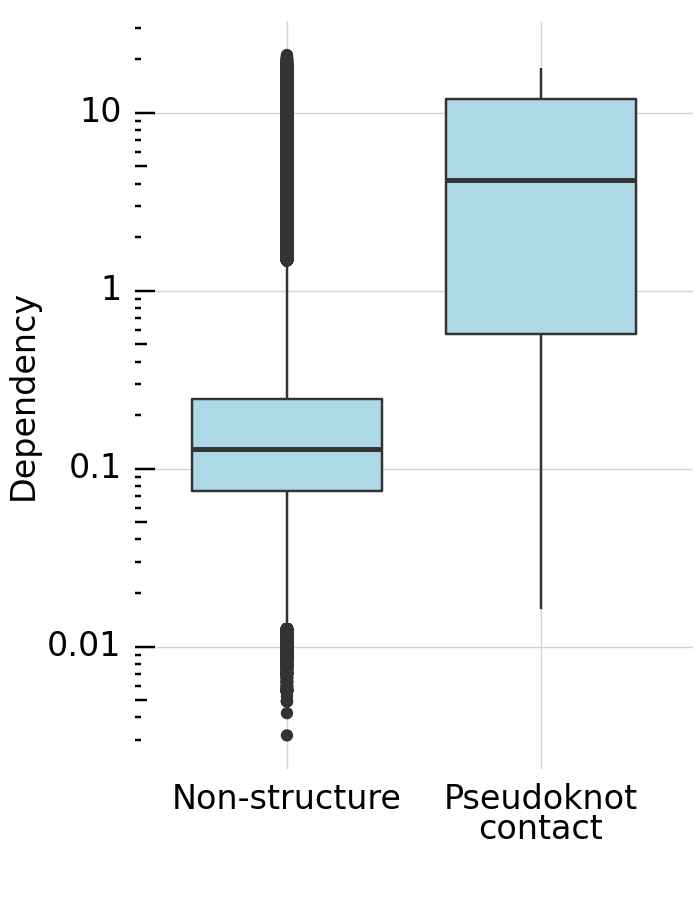

<Figure Size: (350 x 450)>

In [7]:
(ggplot(preds_gt_df[preds_gt_df['preds']>1e-5], aes(x='gt', y='preds')) + geom_boxplot(fill='lightblue') +
    cowplot_theme+ labs(x=' ', y='Dependency') +
    scale_y_log10()+
    annotation_logticks(sides="l"))